In [12]:
pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   --------- ------------------------------ 8.7/36.5 MB 45.7 MB/s eta 0:00:01
   -------------------- ------------------- 18.9/36.5 MB 46.1 MB/s eta 0:00:01
   ------------------------------- -------- 28.3/36.5 MB 46.1 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 46.2 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 42.9 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 41.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 38.6 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 42.0 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillo


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install numpy

   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   --------------------------- ------------ 8.4/12.3 MB 43.7 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 35.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


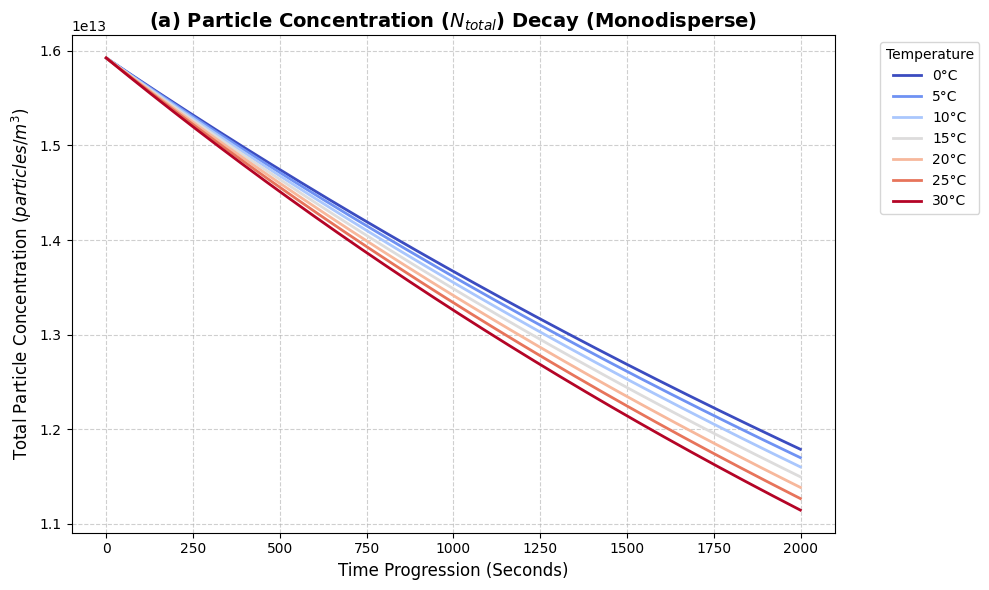

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

temps_c = np.array([0, 5, 10, 15, 20, 25, 30])
rhos_w = np.array([999.8, 1000.0, 999.7, 999.1, 998.2, 997.0, 995.7]) #  (kg/m^3)
mus_base = np.array([1.781, 1.518, 1.307, 1.139, 1.002, 0.890, 0.798])
mus = mus_base * 1e-3 # Pa*s

F_TITLE = 22        
F_LABEL = 20       
F_TICKS = 18       
F_LEGEND = 18      
L_WIDTH = 3.5      
A_ALPHA = 0.9      

def simulate_N_temp_mono_corrected(temp_c, mu, rho_w, total_steps=2000):
    T = temp_c + 273.15
    G = 25.0
    alpha = 0.5
    rho_p = 2650.0  
    df = 2.3
    d0 = 1e-6       
    kb = 1.38e-23
    
    n_bins = 20
    v0 = (np.pi/6) * d0**3
    v_bins = v0 * (2**np.arange(n_bins))
    d_bins = (6*v_bins/np.pi)**(1/3)
    
    N = np.zeros(n_bins)
    
    # 2.  ni = ntu(g/L)*1000 / 6.28e-13
    ntu_g_L = 0.01
    N[0] = ntu_g_L * 1000 / 6.28e-13 # 
    
    beta = np.zeros((n_bins, n_bins))
    for i in range(n_bins):
        for j in range(n_bins):
            di, dj = d_bins[i], d_bins[j]
            b_br = (2*kb*T)/(3*mu) * (di+dj)**2 / (di*dj)
            b_sh = (1/6) * G * (di+dj)**3
            
            rho_floc_i = rho_w + (rho_p - rho_w) * (d0/di)**(3-df) if di > d0 else rho_p
            vi_settle = (9.81 * (rho_floc_i - rho_w) * di**2) / (18 * mu)
            
            rho_floc_j = rho_w + (rho_p - rho_w) * (d0/dj)**(3-df) if dj > d0 else rho_p
            vj_settle = (9.81 * (rho_floc_j - rho_w) * dj**2) / (18 * mu)
            
            b_ds = (np.pi/4) * (di+dj)**2 * abs(vi_settle - vj_settle)
            
            beta[i,j] = b_br + b_sh + b_ds

    dt = 1.0 
    N_total_history = []
    
    for step in range(total_steps):
        N_total_history.append(np.sum(N))
        
        dN = np.zeros(n_bins)
        
        for i in range(n_bins):
            for j in range(i, n_bins):
                #  (i==j)  (i!=j)
                if i == j:
                    rate = 0.5 * alpha * beta[i,i] * (N[i]**2) * dt
                else:
                    rate = alpha * beta[i,j] * N[i] * N[j] * dt
                
                if rate <= 0: continue
                
                if i == j:
                    rate = min(rate, N[i] / 2.0)
                else:
                    rate = min(rate, min(N[i], N[j]))
                
                if rate <= 0: continue
                
                v_new = v_bins[i] + v_bins[j] 
                
                if v_new >= v_bins[-1]:

                    dN[i] -= rate * (2 if i==j else 1)
                    if i != j: dN[j] -= rate
                    dN[-1] += rate * (v_new / v_bins[-1])
                else:
                    k = np.searchsorted(v_bins, v_new, side='right') - 1
                    if k < n_bins - 1:
                        f = (v_bins[k+1] - v_new) / (v_bins[k+1] - v_bins[k])
                        dN[i] -= rate * (2 if i==j else 1)
                        if i != j: dN[j] -= rate
                        dN[k] += f * rate
                        dN[k+1] += (1 - f) * rate
                    else:
                        dN[i] -= rate * (2 if i==j else 1)
                        if i != j: dN[j] -= rate
                        dN[-1] += rate * (v_new / v_bins[-1])
                        
        N += dN
        N[N < 0] = 0 
    return N_total_history


results_N = []
for i in range(len(temps_c)):
    results_N.append(simulate_N_temp_mono_corrected(temps_c[i], mus[i], rhos_w[i], 2000))


plt.figure(figsize=(10, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(temps_c))) 

for i in range(len(temps_c)):
    plt.plot(results_N[i], label=f'{temps_c[i]}°C', color=colors[i], linewidth=2.0)

plt.title("(a) Particle Concentration ($N_{total}$) Decay (Monodisperse)", fontsize=14, fontweight='bold')
plt.xlabel("Time Progression (Seconds)", fontsize=12)
plt.ylabel("Total Particle Concentration ($particles/m^3$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Temperature", fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('coagulation_N_total_decay_mono_corrected.png', dpi=300)
plt.show()

<>:136: SyntaxWarning: invalid escape sequence '\m'
<>:136: SyntaxWarning: invalid escape sequence '\m'
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\1422175979.py:136: SyntaxWarning: invalid escape sequence '\m'
  plt.title("(b) Particle Concentration ($N_{total}$) Decay (Normal Distribution on 2$\mu m$)", fontsize=14, fontweight='bold')


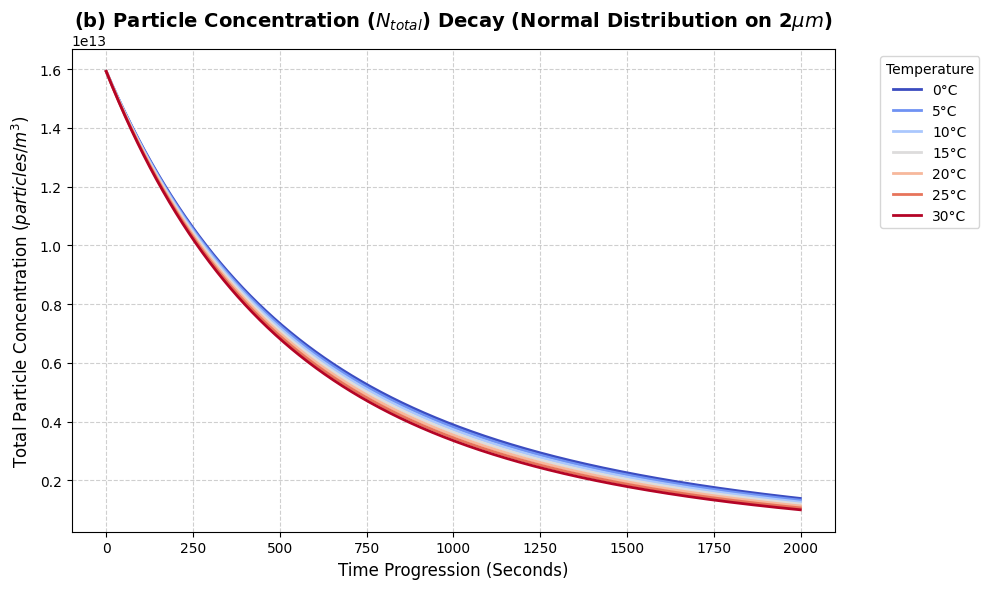

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm


temps_c = np.array([0, 5, 10, 15, 20, 25, 30])
rhos_w = np.array([999.8, 1000.0, 999.7, 999.1, 998.2, 997.0, 995.7]) #  (kg/m^3)
mus_base = np.array([1.781, 1.518, 1.307, 1.139, 1.002, 0.890, 0.798])
mus = mus_base * 1e-3 # (Pa*s)


F_TITLE = 22       
F_LABEL = 20      
F_TICKS = 18       
F_LEGEND = 18      
L_WIDTH = 3.5      
A_ALPHA = 0.9      
def simulate_N_temp_lognormal(temp_c, mu, rho_w, total_steps=2000):
    T = temp_c + 273.15
    G = 25.0        #  (s^-1)
    alpha = 0.5     
    rho_p = 2650.0  # (kg/m^3)
    df = 2.3         
    d0 = 1e-6       #  (1 um)
    kb = 1.38e-23   
    
    n_bins = 30
    v0 = (np.pi/6) * d0**3
    v_bins = v0 * (1.5**np.arange(n_bins))
    d_bins = (6*v_bins/np.pi)**(1/3)
    
    # ---------------------------------------------------------
    # 2. Log-Normal Distribution
    # ---------------------------------------------------------
    mu_g = 2e-6   # (2 um)
    sigma_g = 1.8 # std
    s = np.log(sigma_g)
    
    unnormalized_N = lognorm.pdf(d_bins, s=s, scale=mu_g)
    
    ntu_g_L = 0.01
    target_N_total = ntu_g_L * 1000 / 6.28e-13
    
    N = unnormalized_N * (target_N_total / np.sum(unnormalized_N))
    

    beta = np.zeros((n_bins, n_bins))
    for i in range(n_bins):
        for j in range(n_bins):
            di, dj = d_bins[i], d_bins[j]
            b_br = (2*kb*T)/(3*mu) * (di+dj)**2 / (di*dj)
            b_sh = (1/6) * G * (di+dj)**3
            

            rho_floc_i = rho_w + (rho_p - rho_w) * (d0/di)**(3-df) if di > d0 else rho_p
            vi_settle = (9.81 * (rho_floc_i - rho_w) * di**2) / (18 * mu)
            
            rho_floc_j = rho_w + (rho_p - rho_w) * (d0/dj)**(3-df) if dj > d0 else rho_p
            vj_settle = (9.81 * (rho_floc_j - rho_w) * dj**2) / (18 * mu)
            
            b_ds = (np.pi/4) * (di+dj)**2 * abs(vi_settle - vj_settle)
            beta[i,j] = b_br + b_sh + b_ds


    dt = 1.0 
    N_total_history = []
    
    for step in range(total_steps):
        N_total_history.append(np.sum(N))
        
        dN = np.zeros(n_bins)
        
        for i in range(n_bins):
            for j in range(i, n_bins):
                # (i==j)  (i!=j)
                if i == j:
                    rate = 0.5 * alpha * beta[i,i] * (N[i]**2) * dt
                else:
                    rate = alpha * beta[i,j] * N[i] * N[j] * dt
                
                if rate <= 0: continue
                
                if i == j:
                    rate = min(rate, N[i] / 2.0)
                else:
                    rate = min(rate, min(N[i], N[j]))
                
                if rate <= 0: continue
                
                v_new = v_bins[i] + v_bins[j] 
                
                if v_new >= v_bins[-1]:
                    dN[i] -= rate * (2 if i==j else 1)
                    if i != j: dN[j] -= rate
                    dN[-1] += rate * (v_new / v_bins[-1])
                else:
                    k = np.searchsorted(v_bins, v_new, side='right') - 1
                    if k < n_bins - 1:
                        f = (v_bins[k+1] - v_new) / (v_bins[k+1] - v_bins[k])
                        dN[i] -= rate * (2 if i==j else 1)
                        if i != j: dN[j] -= rate
                        dN[k] += f * rate
                        dN[k+1] += (1 - f) * rate
                    else:
                        dN[i] -= rate * (2 if i==j else 1)
                        if i != j: dN[j] -= rate
                        dN[-1] += rate * (v_new / v_bins[-1])
                        
        N += dN
        N[N < 0] = 0 
        
    return N_total_history

results_N_lognorm = []
for i in range(len(temps_c)):
    results_N_lognorm.append(simulate_N_temp_lognormal(temps_c[i], mus[i], rhos_w[i], 2000))

plt.figure(figsize=(10, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(temps_c)))

for i in range(len(temps_c)):
    plt.plot(results_N_lognorm[i], label=f'{temps_c[i]}°C', color=colors[i], linewidth=2.0)

plt.title("(b) Particle Concentration ($N_{total}$) Decay (Normal Distribution on 2$\mu m$)", fontsize=14, fontweight='bold')
plt.xlabel("Time Progression (Seconds)", fontsize=12)
plt.ylabel("Total Particle Concentration ($particles/m^3$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Temperature", fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('coagulation_N_total_decay_lognormal.png', dpi=300)
plt.show()

<>:134: SyntaxWarning: invalid escape sequence '\m'
<>:134: SyntaxWarning: invalid escape sequence '\m'
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\3841175472.py:134: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Particle Diameter ($\mu m$)", fontsize=12)


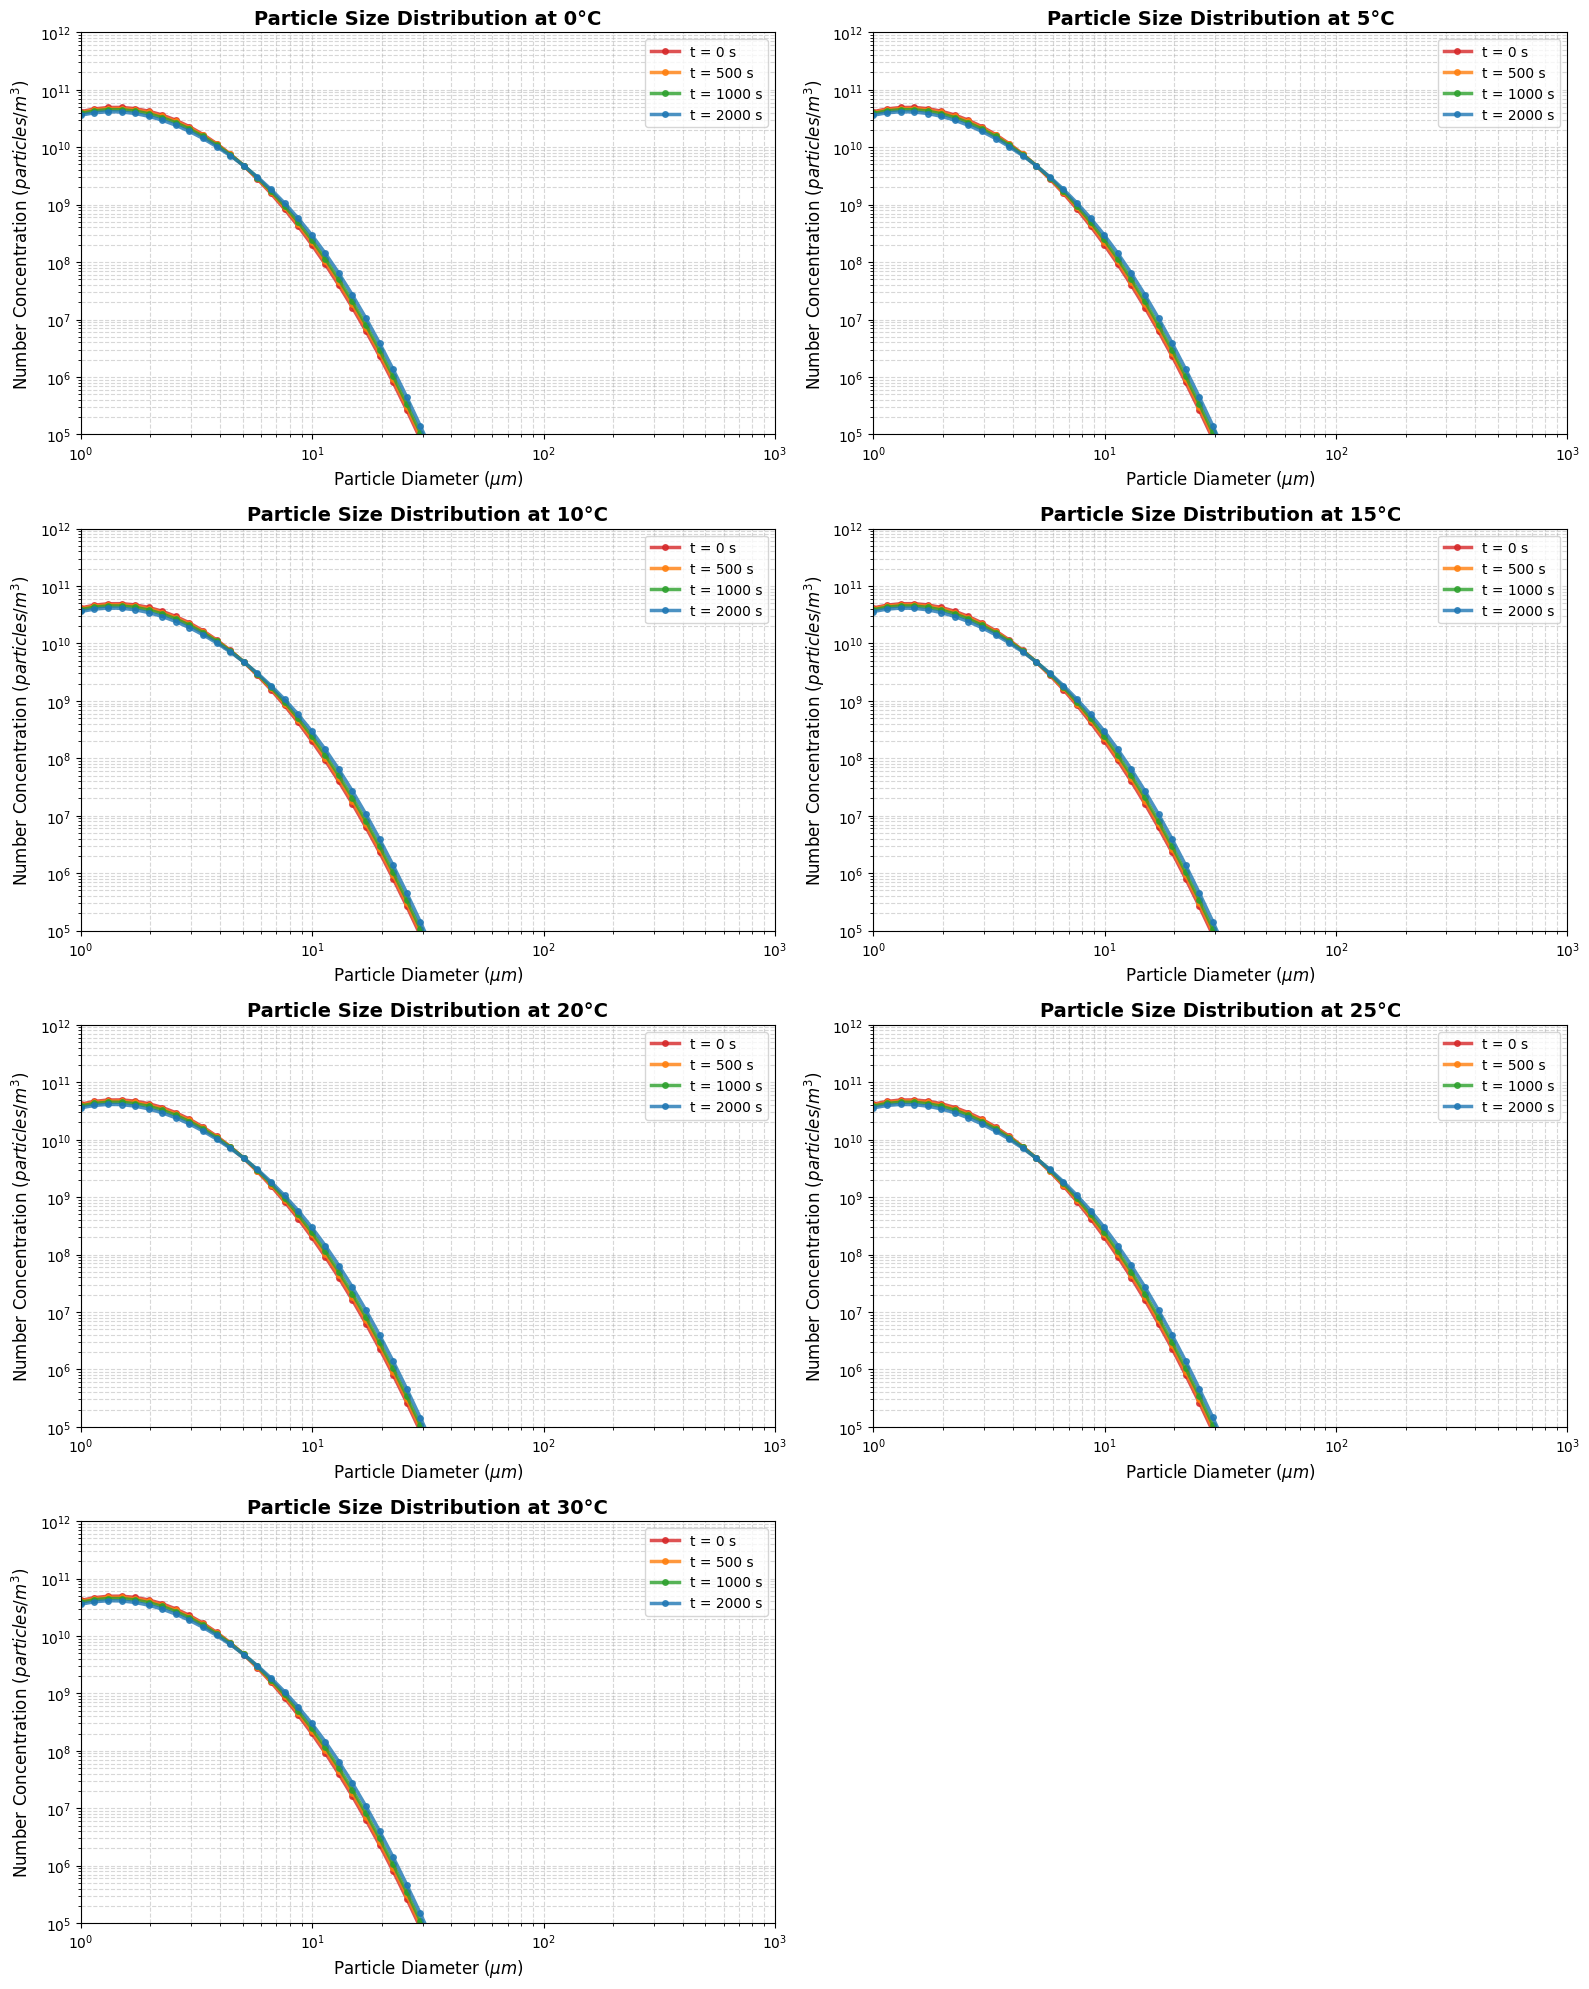

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# 1. 物理參數 (源自講義 Table C-1)
temps_c = np.array([0, 5, 10, 15, 20, 25, 30])
rhos_w = np.array([999.8, 1000.0, 999.7, 999.1, 998.2, 997.0, 995.7]) 
mus_base = np.array([1.781, 1.518, 1.307, 1.139, 1.002, 0.890, 0.798])
mus = mus_base * 1e-3 # 動態黏滯係數 (Pa*s)

def simulate_lognormal_distribution_corrected(temp_c, mu, rho_w, total_steps=2000):
    T = temp_c + 273.15
    G = 50.0
    alpha = 0.5
    rho_p = 2650.0  
    df = 2.3
    d0 = 1e-6
    kb = 1.38e-23
    
    # 粒徑 Bins
    n_bins = 30
    v0 = (np.pi/6) * d0**3
    v_bins = v0 * (1.5**np.arange(n_bins)) # 每次體積乘以 1.5 倍
    d_bins = (6*v_bins/np.pi)**(1/3)
    
    # 引入對數常態分佈
    mu_g = 2e-6   # 幾何平均粒徑 2 微米
    sigma_g = 1.8 # 分佈的寬度
    s = np.log(sigma_g)
    unnormalized_N = lognorm.pdf(d_bins, s=s, scale=mu_g)
    
    # 正規化質量 (0.01 kg/m^3)
    target_vol_conc = 0.01 / rho_p 
    current_vol_conc = np.sum(unnormalized_N * v_bins)
    N = unnormalized_N * (target_vol_conc / current_vol_conc)
    
    # 預計算 Beta 碰撞核矩陣
    beta = np.zeros((n_bins, n_bins))
    for i in range(n_bins):
        for j in range(n_bins):
            di, dj = d_bins[i], d_bins[j]
            b_br = (2*kb*T)/(3*mu) * (di+dj)**2 / (di*dj)
            b_sh = (1/6) * G * (di+dj)**3
            
            rho_floc_i = rho_w + (rho_p - rho_w) * (d0/di)**(3-df) if di > d0 else rho_p
            vi_settle = (9.81 * (rho_floc_i - rho_w) * di**2) / (18 * mu)
            
            rho_floc_j = rho_w + (rho_p - rho_w) * (d0/dj)**(3-df) if dj > d0 else rho_p
            vj_settle = (9.81 * (rho_floc_j - rho_w) * dj**2) / (18 * mu)
            
            b_ds = (np.pi/4) * (di+dj)**2 * abs(vi_settle - vj_settle)
            beta[i,j] = b_br + b_sh + b_ds

    dt = 1.0 
    record_times = [0, 500, 1000, 2000]
    snapshots = {}
    
    for step in range(total_steps + 1):
        if step in record_times:
            snapshots[step] = N.copy()
            
        dN = np.zeros(n_bins)
        
        # --- 核心修正：包含所有不同粒徑的交叉碰撞 (Cross-collisions) ---
        for i in range(n_bins):
            for j in range(i, n_bins):
                if i == j:
                    rate = 0.5 * alpha * beta[i,i] * (N[i]**2) * dt
                else:
                    rate = alpha * beta[i,j] * N[i] * N[j] * dt
                
                if rate <= 0: continue
                
                # 安全機制：避免單一步長扣除超過現有顆粒數
                if i == j:
                    rate = min(rate, N[i] / 2.0)
                else:
                    rate = min(rate, min(N[i], N[j]))
                if rate <= 0: continue
                
                v_new = v_bins[i] + v_bins[j] # 碰撞後的新體積
                
                # 質量守恆分配到最近的 Bins
                if v_new >= v_bins[-1]:
                    # 若超過最大上限，則累積在最後一個 bin
                    dN[i] -= rate * (2 if i==j else 1)
                    if i != j: dN[j] -= rate
                    dN[-1] += rate * (v_new / v_bins[-1])
                else:
                    # 尋找落在哪兩個 bin 之間
                    k = np.searchsorted(v_bins, v_new, side='right') - 1
                    if k < n_bins - 1:
                        f = (v_bins[k+1] - v_new) / (v_bins[k+1] - v_bins[k])
                        dN[i] -= rate * (2 if i==j else 1)
                        if i != j: dN[j] -= rate
                        dN[k] += f * rate
                        dN[k+1] += (1 - f) * rate
                    else:
                        dN[i] -= rate * (2 if i==j else 1)
                        if i != j: dN[j] -= rate
                        dN[-1] += rate * (v_new / v_bins[-1])
                        
        N += dN
        N[N < 0] = 0 # 確保不產生負值
        
    return d_bins, snapshots

# --- 準備畫圖 ---
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

# 調整 Y 軸範圍以適應對數常態的濃度
y_min, y_max = 1e5, 1e12
x_min, x_max = 1e0, 1e3 # 1 um 到 1000 um

time_colors = {
    0: '#d62728',   # 紅 (初始)
    500: '#ff7f0e', # 橘
    1000: '#2ca02c',# 綠
    2000: '#1f77b4' # 藍 (最終)
}

for idx, (temp, mu, rho_w) in enumerate(zip(temps_c, mus, rhos_w)):
    ax = axes[idx]
    d_bins, snapshots = simulate_lognormal_distribution_corrected(temp, mu, rho_w, 2000)
    
    for t_step, dist in snapshots.items():
        dist_plot = np.where(dist <= 0, 1e-10, dist)
        ax.plot(d_bins * 1e6, dist_plot, marker='o', linestyle='-', 
                color=time_colors[t_step], label=f't = {t_step} s', 
                linewidth=2.5, markersize=4, alpha=0.8)
    
    ax.set_title(f"Particle Size Distribution at {temp}°C", fontsize=14, fontweight='bold')
    ax.set_xlabel("Particle Diameter ($\mu m$)", fontsize=12)
    ax.set_ylabel("Number Concentration ($particles/m^3$)", fontsize=12)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend(fontsize=10)

axes[7].axis('off')
plt.tight_layout()
plt.savefig('psd_lognormal_corrected.png', dpi=300)
plt.show()

<>:134: SyntaxWarning: invalid escape sequence '\m'
<>:134: SyntaxWarning: invalid escape sequence '\m'
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\386662782.py:134: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Particle Diameter ($\mu m$)", fontsize=12)


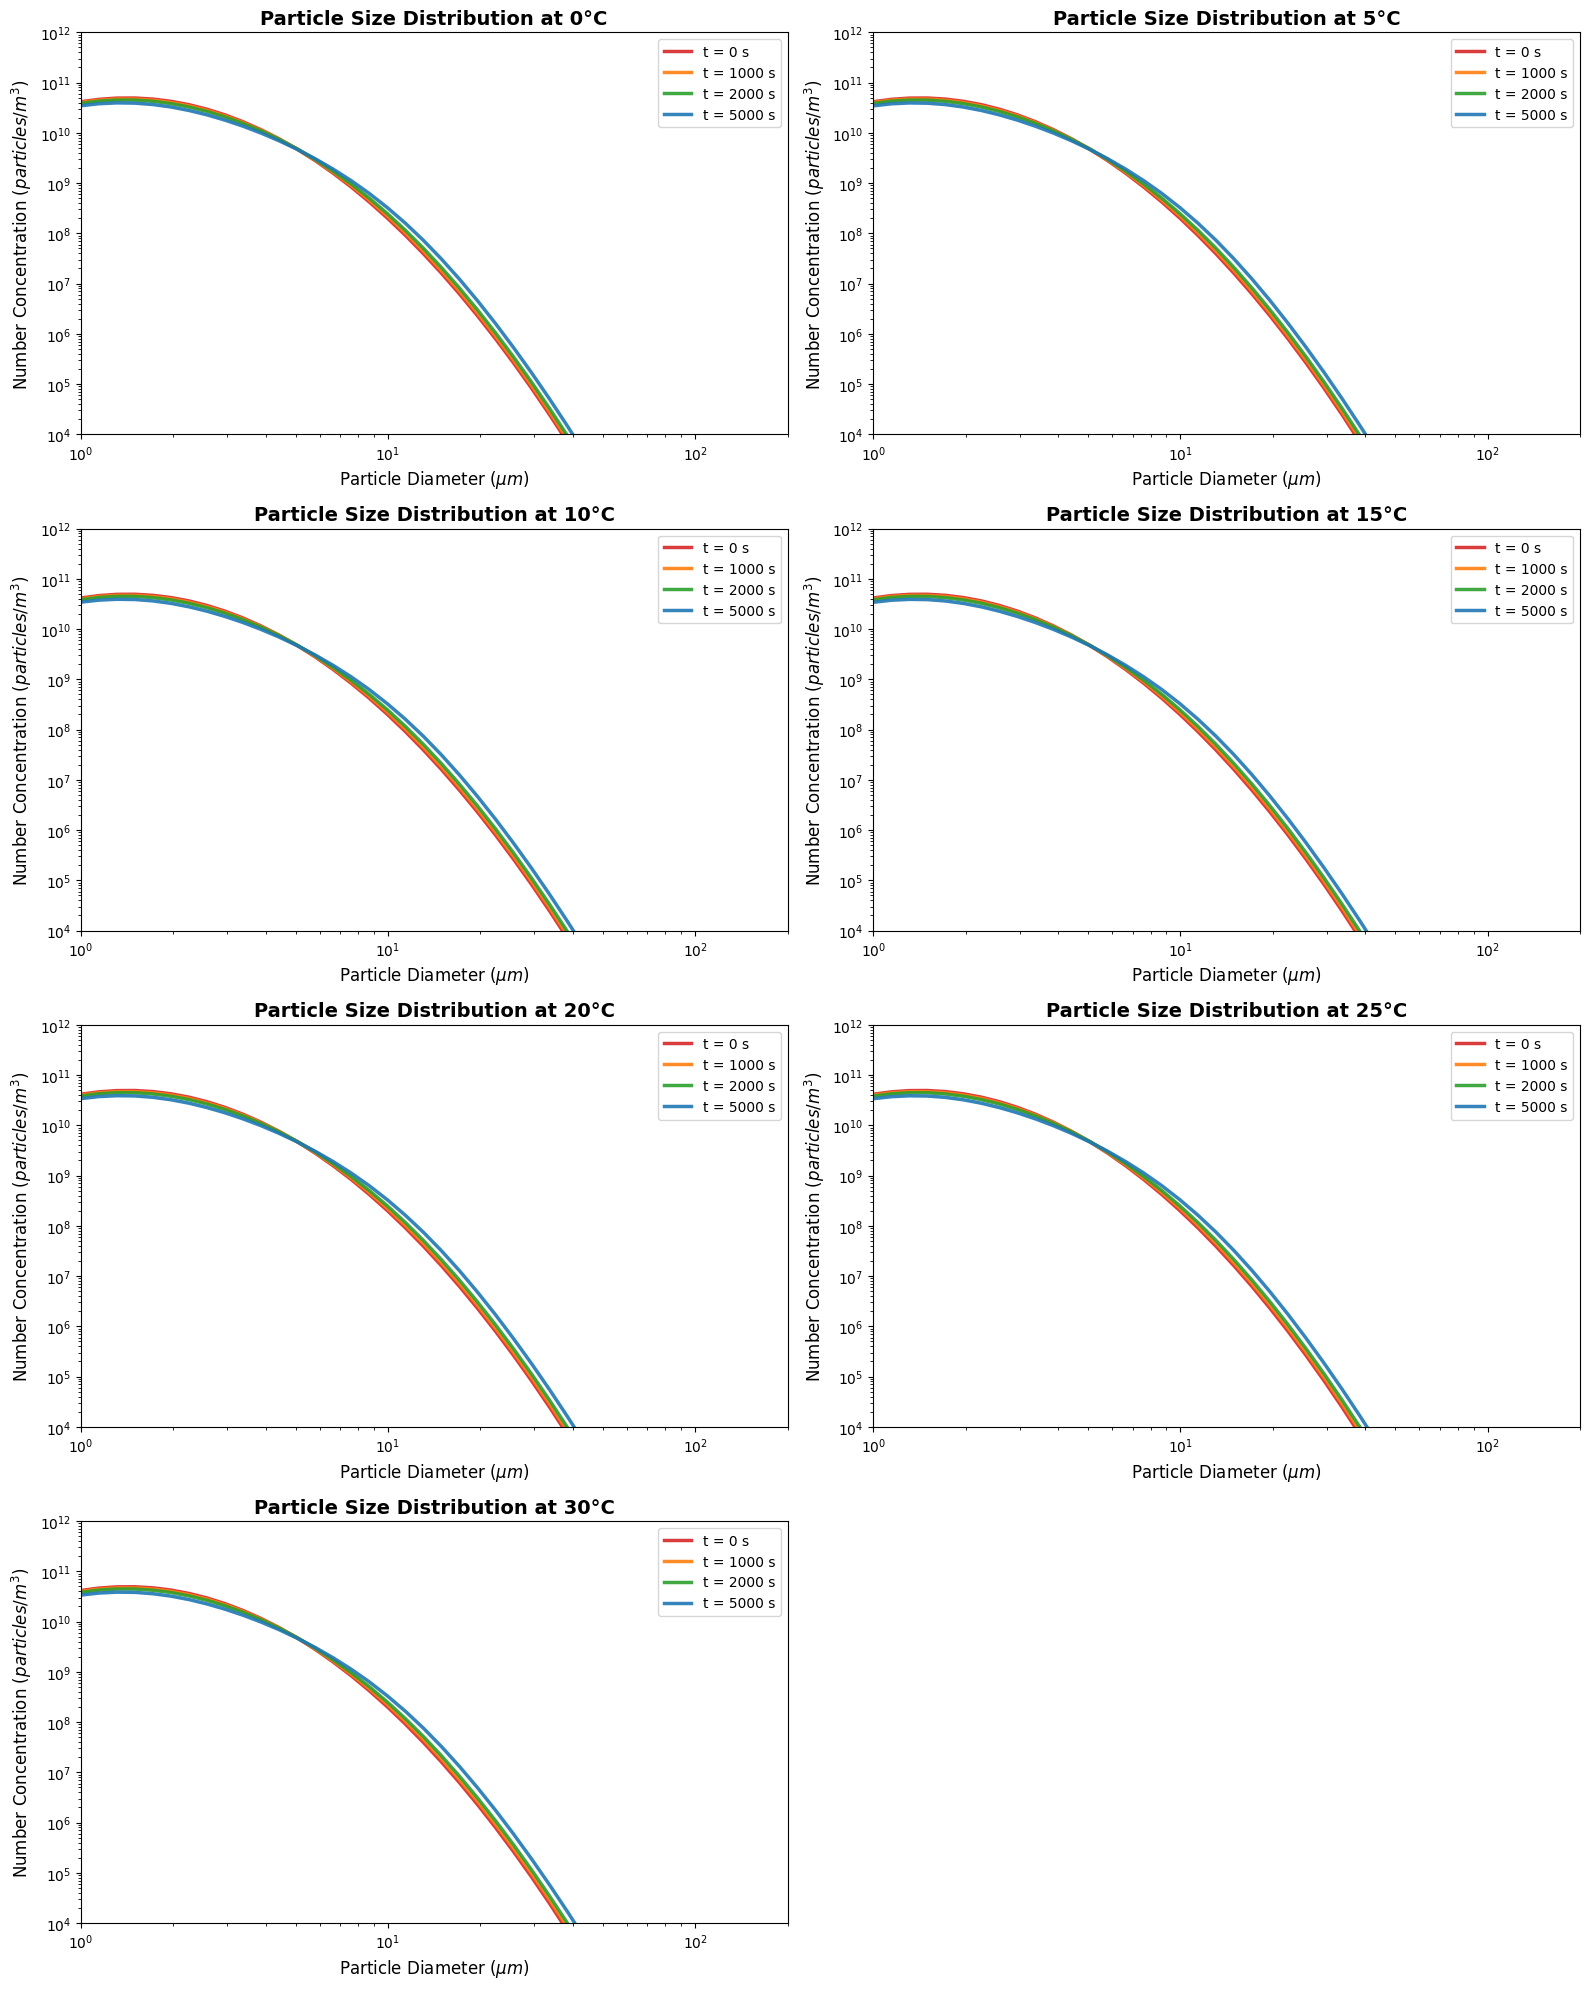

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# 1. 物理參數 (源自講義 Table C-1)
temps_c = np.array([0, 5, 10, 15, 20, 25, 30])
rhos_w = np.array([999.8, 1000.0, 999.7, 999.1, 998.2, 997.0, 995.7]) 
mus_base = np.array([1.781, 1.518, 1.307, 1.139, 1.002, 0.890, 0.798])
mus = mus_base * 1e-3 # 動態黏滯係數 (Pa*s)

def simulate_lognormal_distribution_corrected(temp_c, mu, rho_w, total_steps=5000):
    T = temp_c + 273.15
    G = 25.0
    alpha = 0.5
    rho_p = 2650.0  
    df = 2.3
    d0 = 1e-6
    kb = 1.38e-23
    
    # 將粒徑 Bins 增加至 45，避免 t=5000 產生的大顆粒堆積在最後一個 bin 形成異常突起
    n_bins = 45
    v0 = (np.pi/6) * d0**3
    v_bins = v0 * (1.5**np.arange(n_bins)) # 每次體積乘以 1.5 倍
    d_bins = (6*v_bins/np.pi)**(1/3)
    
    # 引入對數常態分佈
    mu_g = 2e-6   # 幾何平均粒徑 2 微米
    sigma_g = 1.8 # 分佈的寬度
    s = np.log(sigma_g)
    unnormalized_N = lognorm.pdf(d_bins, s=s, scale=mu_g)
    
    # 正規化質量 (0.01 kg/m^3)
    target_vol_conc = 0.01 / rho_p 
    current_vol_conc = np.sum(unnormalized_N * v_bins)
    N = unnormalized_N * (target_vol_conc / current_vol_conc)
    
    # 預計算 Beta 碰撞核矩陣
    beta = np.zeros((n_bins, n_bins))
    for i in range(n_bins):
        for j in range(n_bins):
            di, dj = d_bins[i], d_bins[j]
            b_br = (2*kb*T)/(3*mu) * (di+dj)**2 / (di*dj)
            b_sh = (1/6) * G * (di+dj)**3
            
            rho_floc_i = rho_w + (rho_p - rho_w) * (d0/di)**(3-df) if di > d0 else rho_p
            vi_settle = (9.81 * (rho_floc_i - rho_w) * di**2) / (18 * mu)
            
            rho_floc_j = rho_w + (rho_p - rho_w) * (d0/dj)**(3-df) if dj > d0 else rho_p
            vj_settle = (9.81 * (rho_floc_j - rho_w) * dj**2) / (18 * mu)
            
            b_ds = (np.pi/4) * (di+dj)**2 * abs(vi_settle - vj_settle)
            beta[i,j] = b_br + b_sh + b_ds

    dt = 1.0 
    # 更新紀錄時間點至 5000
    record_times = [0, 1000, 2000, 5000]
    snapshots = {}
    
    for step in range(total_steps + 1):
        if step in record_times:
            snapshots[step] = N.copy()
            
        dN = np.zeros(n_bins)
        
        # 包含所有不同粒徑的交叉碰撞
        for i in range(n_bins):
            for j in range(i, n_bins):
                if i == j:
                    rate = 0.5 * alpha * beta[i,i] * (N[i]**2) * dt
                else:
                    rate = alpha * beta[i,j] * N[i] * N[j] * dt
                
                if rate <= 0: continue
                
                # 安全機制
                if i == j:
                    rate = min(rate, N[i] / 2.0)
                else:
                    rate = min(rate, min(N[i], N[j]))
                if rate <= 0: continue
                
                v_new = v_bins[i] + v_bins[j] 
                
                # 質量守恆分配到最近的 Bins
                if v_new >= v_bins[-1]:
                    dN[i] -= rate * (2 if i==j else 1)
                    if i != j: dN[j] -= rate
                    dN[-1] += rate * (v_new / v_bins[-1])
                else:
                    k = np.searchsorted(v_bins, v_new, side='right') - 1
                    if k < n_bins - 1:
                        f = (v_bins[k+1] - v_new) / (v_bins[k+1] - v_bins[k])
                        dN[i] -= rate * (2 if i==j else 1)
                        if i != j: dN[j] -= rate
                        dN[k] += f * rate
                        dN[k+1] += (1 - f) * rate
                    else:
                        dN[i] -= rate * (2 if i==j else 1)
                        if i != j: dN[j] -= rate
                        dN[-1] += rate * (v_new / v_bins[-1])
                        
        N += dN
        N[N < 0] = 0 
        
    return d_bins, snapshots

# --- 準備畫圖 ---
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

# 調整合理且不空泛的座標軸範圍
y_min, y_max = 1e4, 1e12
x_min, x_max = 1e0, 2e2 # 將 X 軸最大值縮至 200 um

time_colors = {
    0: '#d62728',     # 紅 (初始)
    1000: '#ff7f0e',  # 橘
    2000: '#2ca02c',  # 綠
    5000: '#1f77b4'   # 藍 (最終 t=5000)
}

for idx, (temp, mu, rho_w) in enumerate(zip(temps_c, mus, rhos_w)):
    ax = axes[idx]
    d_bins, snapshots = simulate_lognormal_distribution_corrected(temp, mu, rho_w, total_steps=5000)
    
    for t_step, dist in snapshots.items():
        dist_plot = np.where(dist <= 0, 1e-10, dist)
        # 移除了 marker='o'，只留下純曲線
        ax.plot(d_bins * 1e6, dist_plot, linestyle='-', 
                color=time_colors[t_step], label=f't = {t_step} s', 
                linewidth=2.5, alpha=0.9)
    
    ax.set_title(f"Particle Size Distribution at {temp}°C", fontsize=14, fontweight='bold')
    ax.set_xlabel("Particle Diameter ($\mu m$)", fontsize=12)
    ax.set_ylabel("Number Concentration ($particles/m^3$)", fontsize=12)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    # 移除了 ax.grid() 以去掉背景網狀格線
    ax.legend(fontsize=10)

axes[7].axis('off')
plt.tight_layout()
plt.savefig('psd_lognormal_t5000_clean.png', dpi=300)
plt.show()

<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\m'
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\2191393375.py:84: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Particle Diameter ($\mu m$)", fontsize=13)


正在模擬不同溫度下的粒徑分佈 (t=5000s)...


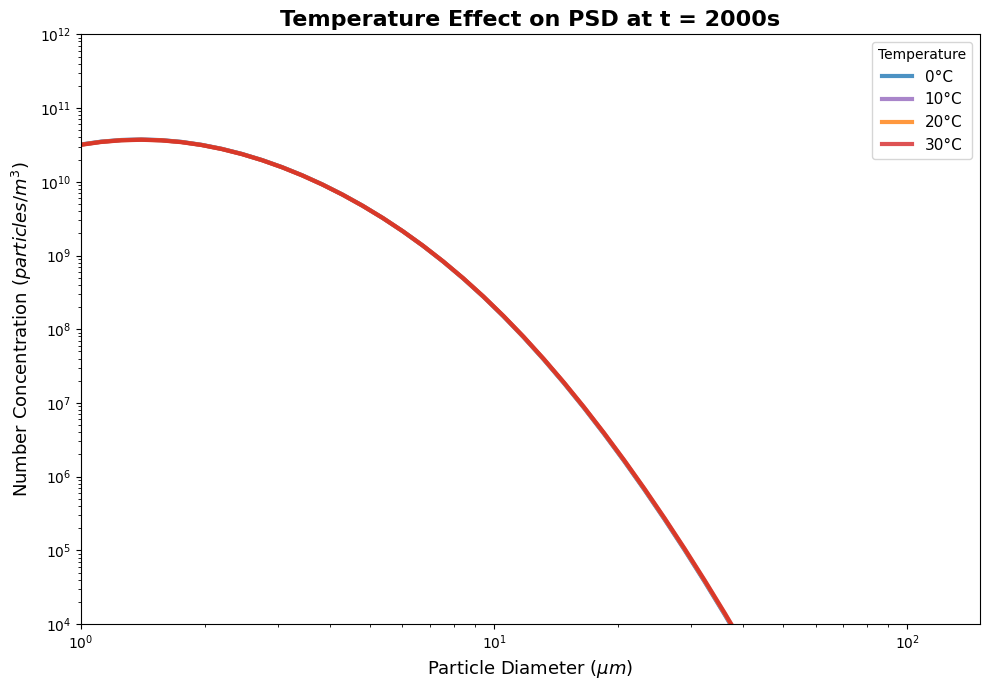

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# 1. 物理參數 (選取四個代表性溫度)
selected_temps = np.array([0, 10, 20, 30])
# 相對應的密度與黏度 (Pa*s)
selected_rhos = np.array([999.8, 999.7, 998.2, 995.7])
selected_mus = np.array([1.781, 1.307, 1.002, 0.798]) * 1e-3

def simulate_psd(temp_c, mu, rho_w, total_steps=5000):
    T = temp_c + 273.15
    G = 25.0
    alpha = 0.5
    rho_p = 2650.0  
    df = 2.3
    d0 = 1e-6
    kb = 1.38e-23
    
    n_bins = 50 # 增加 bin 數量讓曲線更平滑
    v0 = (np.pi/6) * d0**3
    v_bins = v0 * (1.4**np.arange(n_bins)) 
    d_bins = (6*v_bins/np.pi)**(1/3)
    
    mu_g, sigma_g = 2e-6, 1.8
    s = np.log(sigma_g)
    unnormalized_N = lognorm.pdf(d_bins, s=s, scale=mu_g)
    target_vol_conc = 0.01 / rho_p 
    current_vol_conc = np.sum(unnormalized_N * v_bins)
    N = unnormalized_N * (target_vol_conc / current_vol_conc)
    
    beta = np.zeros((n_bins, n_bins))
    for i in range(n_bins):
        for j in range(n_bins):
            di, dj = d_bins[i], d_bins[j]
            b_br = (2*kb*T)/(3*mu) * (di+dj)**2 / (di*dj)
            b_sh = (1/6) * G * (di+dj)**3
            rho_fi = rho_w + (rho_p - rho_w) * (d0/di)**(3-df) if di > d0 else rho_p
            vi = (9.81 * (rho_fi - rho_w) * di**2) / (18 * mu)
            rho_fj = rho_w + (rho_p - rho_w) * (d0/dj)**(3-df) if dj > d0 else rho_p
            vj = (9.81 * (rho_fj - rho_w) * dj**2) / (18 * mu)
            b_ds = (np.pi/4) * (di+dj)**2 * abs(vi - vj)
            beta[i,j] = b_br + b_sh + b_ds

    dt = 1.0 
    for step in range(total_steps + 1):
        dN = np.zeros(n_bins)
        for i in range(n_bins):
            for j in range(i, n_bins):
                rate = (0.5 if i==j else 1.0) * alpha * beta[i,j] * N[i] * N[j] * dt
                rate = min(rate, N[i]/2.0 if i==j else min(N[i], N[j]))
                if rate <= 0: continue
                v_new = v_bins[i] + v_bins[j]
                if v_new >= v_bins[-1]:
                    dN[i] -= rate * (2 if i==j else 1)
                    if i != j: dN[j] -= rate
                    dN[-1] += rate * (v_new / v_bins[-1])
                else:
                    k = np.searchsorted(v_bins, v_new, side='right') - 1
                    f = (v_bins[k+1] - v_new) / (v_bins[k+1] - v_bins[k])
                    dN[i] -= rate * (2 if i==j else 1)
                    if i != j: dN[j] -= rate
                    dN[k] += f * rate
                    dN[k+1] += (1 - f) * rate
        N += dN
        N[N < 0] = 0
    return d_bins, N

# --- 繪圖 ---
plt.figure(figsize=(10, 7))
colors = ['#1f77b4', '#9467bd', '#ff7f0e', '#d62728'] # 藍、紫、橘、紅 (冷到熱)

print("正在模擬不同溫度下的粒徑分佈 (t=5000s)...")
for temp, mu, rho, col in zip(selected_temps, selected_mus, selected_rhos, colors):
    d_bins, final_dist = simulate_psd(temp, mu, rho, 2000)
    plt.plot(d_bins * 1e6, final_dist, label=f'{temp}°C', 
             color=col, linewidth=3, alpha=0.8)

plt.xscale('log')
plt.yscale('log')
plt.xlim(1, 150) # 縮小範圍，讓尾部差異放大
plt.ylim(1e4, 1e12)
plt.title("Temperature Effect on PSD at t = 2000s", fontsize=16, fontweight='bold')
plt.xlabel("Particle Diameter ($\mu m$)", fontsize=13)
plt.ylabel("Number Concentration ($particles/m^3$)", fontsize=13)
# 不加網格線，保持專業感
plt.legend(title="Temperature", fontsize=11)
plt.tight_layout()
plt.savefig('temp_comparison_t5000.png', dpi=300)
plt.show()

<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\105321647.py:50: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Particle Diameter ($\mu m$)', fontsize=13)


正在計算並繪製雷諾數關係圖...


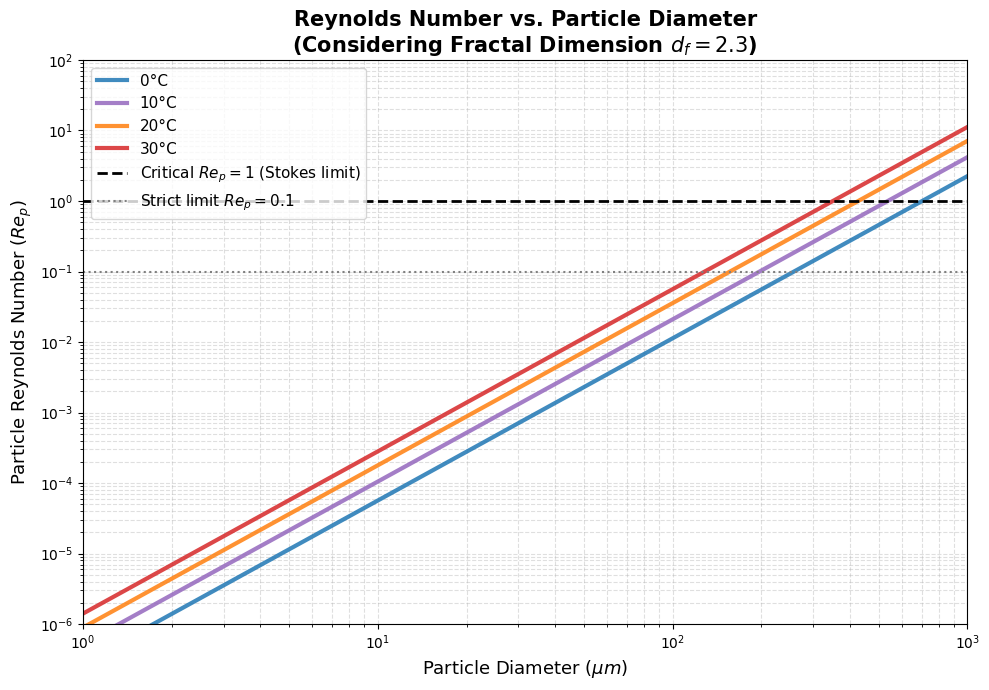

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 基本參數設定 (延續先前的物理條件)
selected_temps = np.array([0, 10, 20, 30])
selected_rhos = np.array([999.8, 999.7, 998.2, 995.7]) # 水密度 (kg/m^3)
selected_mus = np.array([1.781, 1.307, 1.002, 0.798]) * 1e-3 # 動態黏滯係數 (Pa*s)

rho_p = 2650.0  # 原生顆粒密度 (二氧化矽/沙粒等級, kg/m^3)
d0 = 1e-6       # 原生顆粒大小 (1 um)
df = 2.3        # 分形維度 (Fractal Dimension)
g = 9.81        # 重力加速度 (m/s^2)

# 2. 建立粒徑陣列 (從 1 um 到 1000 um)
# 使用對數空間產生 500 個點，讓 Log-Log 座標下的曲線更平滑
d_array = np.logspace(-6, -3, 500) 

# 3. 準備畫圖
plt.figure(figsize=(10, 7))
colors = ['#1f77b4', '#9467bd', '#ff7f0e', '#d62728'] # 藍、紫、橘、紅

print("正在計算並繪製雷諾數關係圖...")

for temp, rho_w, mu, col in zip(selected_temps, selected_rhos, selected_mus, colors):
    # a. 計算絮體有效密度 (考慮分形結構帶來的密度下降)
    rho_floc = rho_w + (rho_p - rho_w) * (d0 / d_array)**(3 - df)
    
    # b. 根據 Stokes Law 計算沉降速度 (m/s)
    v_s = (g * (rho_floc - rho_w) * d_array**2) / (18 * mu)
    
    # c. 計算顆粒雷諾數 (Particle Reynolds Number)
    Re = (rho_w * v_s * d_array) / mu
    
    # 畫出該溫度下的曲線
    plt.plot(d_array * 1e6, Re, color=col, linewidth=3, alpha=0.85, label=f'{temp}°C')

# 4. 畫出判別基準線
# 嚴格的 Stokes Law 適用上限通常抓 Re = 1 (有時更嚴謹會抓 0.1)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='Critical $Re_p = 1$ (Stokes limit)')
plt.axhline(y=0.1, color='gray', linestyle=':', linewidth=1.5, label='Strict limit $Re_p = 0.1$')

# 5. 設定圖表格式
plt.xscale('log')
plt.yscale('log')

# 限制 X 軸與 Y 軸的顯示範圍，聚焦在我們關心的區域
plt.xlim(1, 1000)
plt.ylim(1e-6, 1e2)

plt.xlabel('Particle Diameter ($\mu m$)', fontsize=13)
plt.ylabel('Particle Reynolds Number ($Re_p$)', fontsize=13)
plt.title('Reynolds Number vs. Particle Diameter\n(Considering Fractal Dimension $d_f = 2.3$)', fontsize=15, fontweight='bold')

plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()

# 儲存與顯示
plt.savefig('reynolds_vs_diameter.png', dpi=300)
plt.show()

<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:89: SyntaxWarning: invalid escape sequence '\c'
<>:90: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:89: SyntaxWarning: invalid escape sequence '\c'
<>:90: SyntaxWarning: invalid escape sequence '\m'
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\579384104.py:47: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('Particle Diameter ($\mu m$)', fontsize=F_LABEL)
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\579384104.py:89: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_title('(b) Effect of Floc Structure ($T = 20^\circ C$)', fontsize=F_TITLE, fontweight='bold', pad=20)
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\579384104.py:90: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('Particle Diameter ($\mu m$)', fontsize=F_LABEL)


圖表已成功儲存為 Settling_Velocity_Stacked_Clear_NoGrid.png


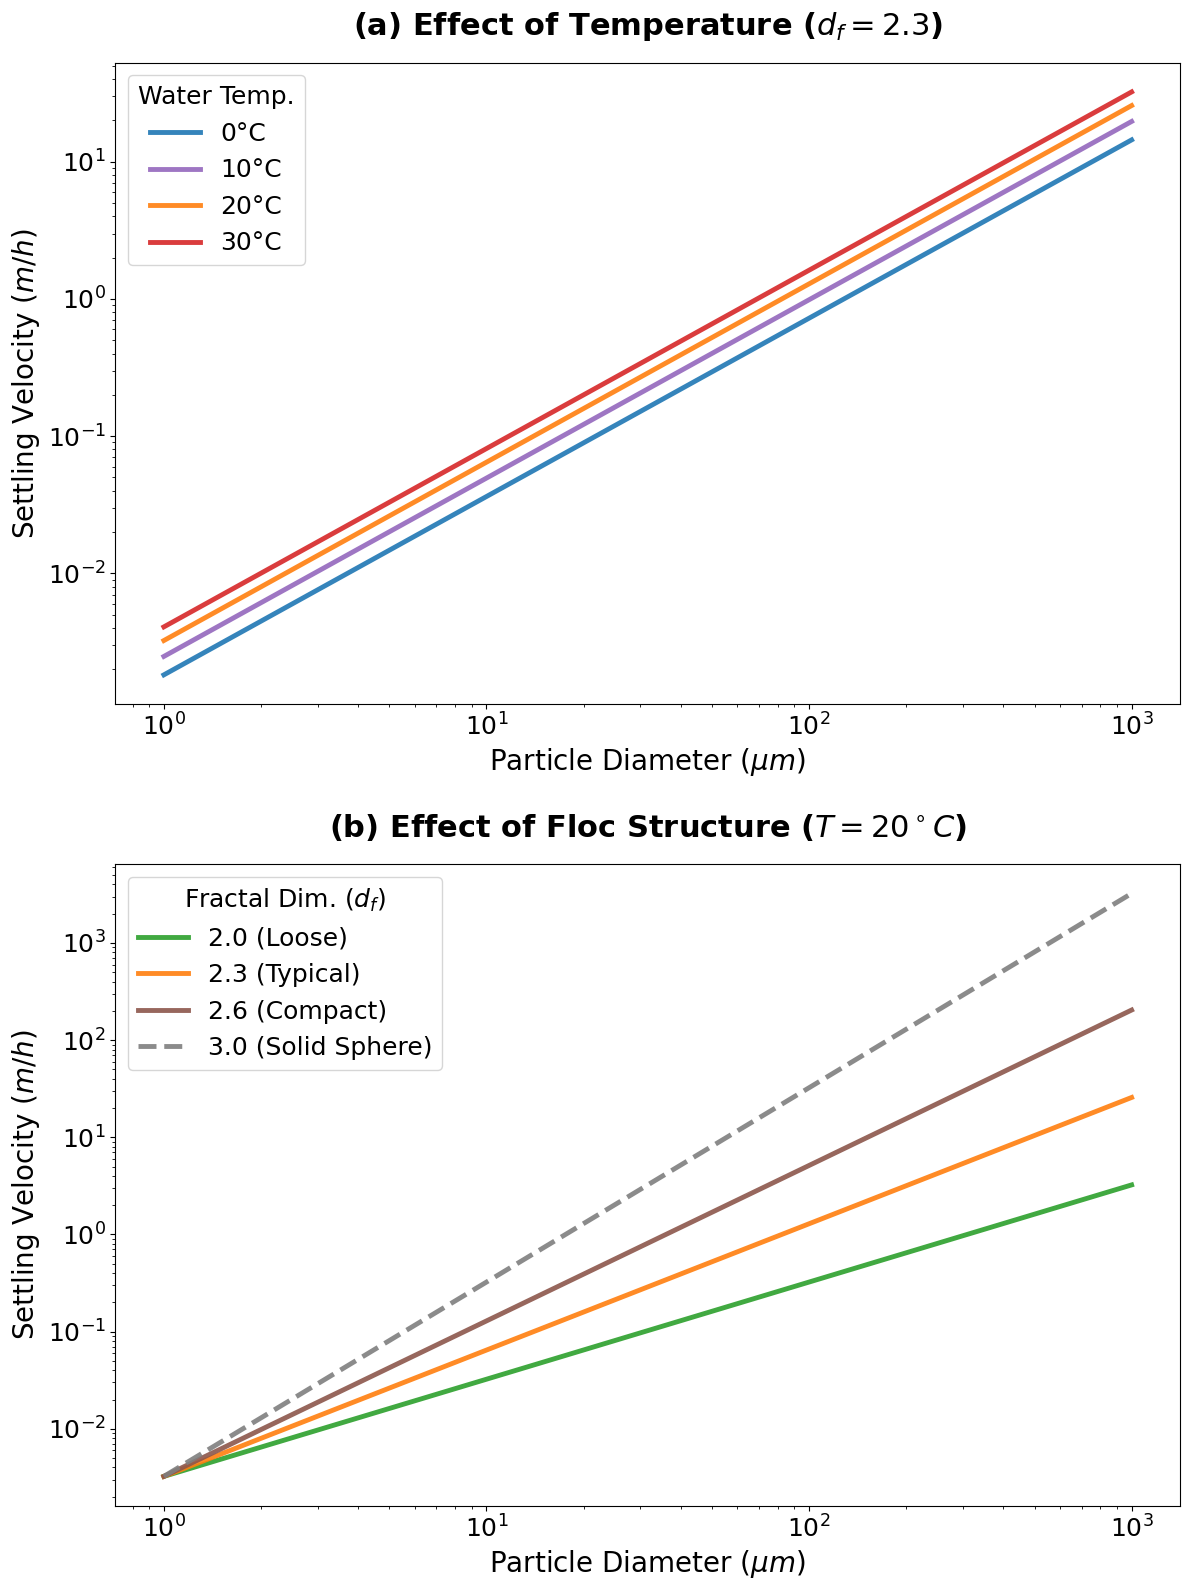

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# === 設定全域字體大小變數，方便統一管理 ===
F_TITLE = 22       # 子圖主標題 (包含 a, b)
F_LABEL = 20       # X, Y 軸標籤
F_TICKS = 18       # 刻度標籤大小 (對數刻度需要更大才清楚)
F_LEGEND = 18      # 圖例文字與圖例標題
L_WIDTH = 3.5      # 線條寬度，配合大圖與大字
A_ALPHA = 0.9      # 線條透明度

# --- 1. 基本物理參數 (保持不變) ---
g = 9.81
rho_p = 2650.0  # 原生顆粒密度 (kg/m^3)
d0 = 1e-6       # 原生顆粒直徑 (1 um)
d_array = np.logspace(-6, -3, 500) # 粒徑範圍 1 um 到 1000 um

# 溫度對應參數 (0, 10, 20, 30 °C)
temps = [0, 10, 20, 30]
rhos_w = [999.8, 999.7, 998.2, 995.7]
mus = [1.781e-3, 1.307e-3, 1.002e-3, 0.798e-3]

# --- 2. 建立 2x1 畫布 (上下堆疊) ---
# 調整 figsize 讓圖表變高，適應上下佈局，並給予足夠空間容納大字體
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16))

# ==============================================================================
# 上圖 (a)：探討「溫度」的影響 (固定 df = 2.3)
# ==============================================================================
df_fixed = 2.3
colors_t = ['#1f77b4', '#9467bd', '#ff7f0e', '#d62728']

for T, rho_w, mu, color in zip(temps, rhos_w, mus, colors_t):
    # 計算有效密度
    rho_floc = rho_w + (rho_p - rho_w) * (d0 / d_array)**(3 - df_fixed)
    # 計算沉降速度 (m/s)
    vs_ms = (g * (rho_floc - rho_w) * d_array**2) / (18 * mu)
    # 轉換為 m/h (公尺/小時) 以符合工程直覺
    vs_mh = vs_ms * 3600 
    
    # 增加線寬 lw=L_WIDTH，增加透明度 alpha
    ax1.plot(d_array * 1e6, vs_mh, label=f'{T}°C', color=color, lw=L_WIDTH, alpha=A_ALPHA)

# --- 設定上圖 (a) 的格式與超大字體 ---
# 標題加入 (a) 標籤
ax1.set_title(f'(a) Effect of Temperature ($d_f = {df_fixed}$)', fontsize=F_TITLE, fontweight='bold', pad=20)
ax1.set_xlabel('Particle Diameter ($\mu m$)', fontsize=F_LABEL)
ax1.set_ylabel('Settling Velocity ($m/h$)', fontsize=F_LABEL)
ax1.set_xscale('log')
ax1.set_yscale('log')

# 設定 X, Y 軸的主、次刻度標籤大小 (對數座標的刻度標籤也需要單獨設定大小)
ax1.tick_params(axis='both', which='major', labelsize=F_TICKS)
ax1.tick_params(axis='both', which='minor', labelsize=F_TICKS) # 確保 minor ticks 也變大

# 已移除 ax1.grid() 以去除網格線

# 設定圖例字體大小與透明度
ax1.legend(title='Water Temp.', fontsize=F_LEGEND, title_fontsize=F_LEGEND, loc='upper left', framealpha=0.8)


# ==============================================================================
# 下圖 (b)：探討「分形維度」的影響 (固定 T = 20°C)
# ==============================================================================
dfs = [2.0, 2.3, 2.6, 3.0]
labels_df = ['2.0 (Loose)', '2.3 (Typical)', '2.6 (Compact)', '3.0 (Solid Sphere)']
colors_df = ['#2ca02c', '#ff7f0e', '#8c564b', '#7f7f7f']

T_fixed_idx = 2 # 使用 20°C 作為基準
rho_w_fixed = rhos_w[T_fixed_idx]
mu_fixed = mus[T_fixed_idx]

for df_val, label, color in zip(dfs, labels_df, colors_df):
    if df_val == 3.0:
        # 實心球的密度不隨粒徑改變
        rho_floc = np.full_like(d_array, rho_p) 
    else:
        rho_floc = rho_w_fixed + (rho_p - rho_w_fixed) * (d0 / d_array)**(3 - df_val)
        
    vs_ms = (g * (rho_floc - rho_w_fixed) * d_array**2) / (18 * mu_fixed)
    vs_mh = vs_ms * 3600
    
    # 特别標示實心球曲線為虛線作為理想對照組，線寬 lw=L_WIDTH
    line_style = '--' if df_val == 3.0 else '-'
    ax2.plot(d_array * 1e6, vs_mh, label=f'{label}', color=color, ls=line_style, lw=L_WIDTH, alpha=A_ALPHA)

# --- 設定下圖 (b) 的格式與超大字體 ---
# 標題加入 (b) 標籤
ax2.set_title('(b) Effect of Floc Structure ($T = 20^\circ C$)', fontsize=F_TITLE, fontweight='bold', pad=20)
ax2.set_xlabel('Particle Diameter ($\mu m$)', fontsize=F_LABEL)
ax2.set_ylabel('Settling Velocity ($m/h$)', fontsize=F_LABEL)
ax2.set_xscale('log')
ax2.set_yscale('log')

# 設定 X, Y 軸的主、次刻度標籤大小
ax2.tick_params(axis='both', which='major', labelsize=F_TICKS)
ax2.tick_params(axis='both', which='minor', labelsize=F_TICKS)

# 已移除 ax2.grid() 以去除網格線

# 設定圖例字體大小與透明度
ax2.legend(title='Fractal Dim. ($d_f$)', fontsize=F_LEGEND, title_fontsize=F_LEGEND, loc='upper left', framealpha=0.8)


# --- 3. 排版與輸出 ---
# 使用 tight_layout 進行初步自動調整
plt.tight_layout()

# 進一步手動調整子圖間距 (因為字體很大，需要給予足夠空間，避免上圖 X 軸標籤與下圖標題重疊)
fig.subplots_adjust(hspace=0.25) # 增加垂直間距 (hspace)

# 儲存高解析度圖片
output_filename = 'Settling_Velocity_Stacked_Clear_NoGrid.png'
plt.savefig(output_filename, dpi=300)
print(f"圖表已成功儲存為 {output_filename}")

plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:99: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:99: SyntaxWarning: invalid escape sequence '\c'
<>:100: SyntaxWarning: invalid escape sequence '\m'
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\993169334.py:49: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('Particle Diameter ($\mu m$)', fontsize=F_LABEL)
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\993169334.py:99: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_title('(b) Effect of Floc Structure ($T = 20^\circ C$)', fontsize=F_TITLE, fontweight='bold', pad=20)
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\993169334.py:100: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel('Particle Diameter ($\mu m$)', fontsize=F_LABEL)
C:\Users\moody\AppData\Local\Temp\ipykernel_33200\993169334.py:69: MatplotlibDeprecationWarning: Since Matplotlib 

圖表已成功儲存為 Settling_Velocity_Stacked_With_Inset_Adjusted.png


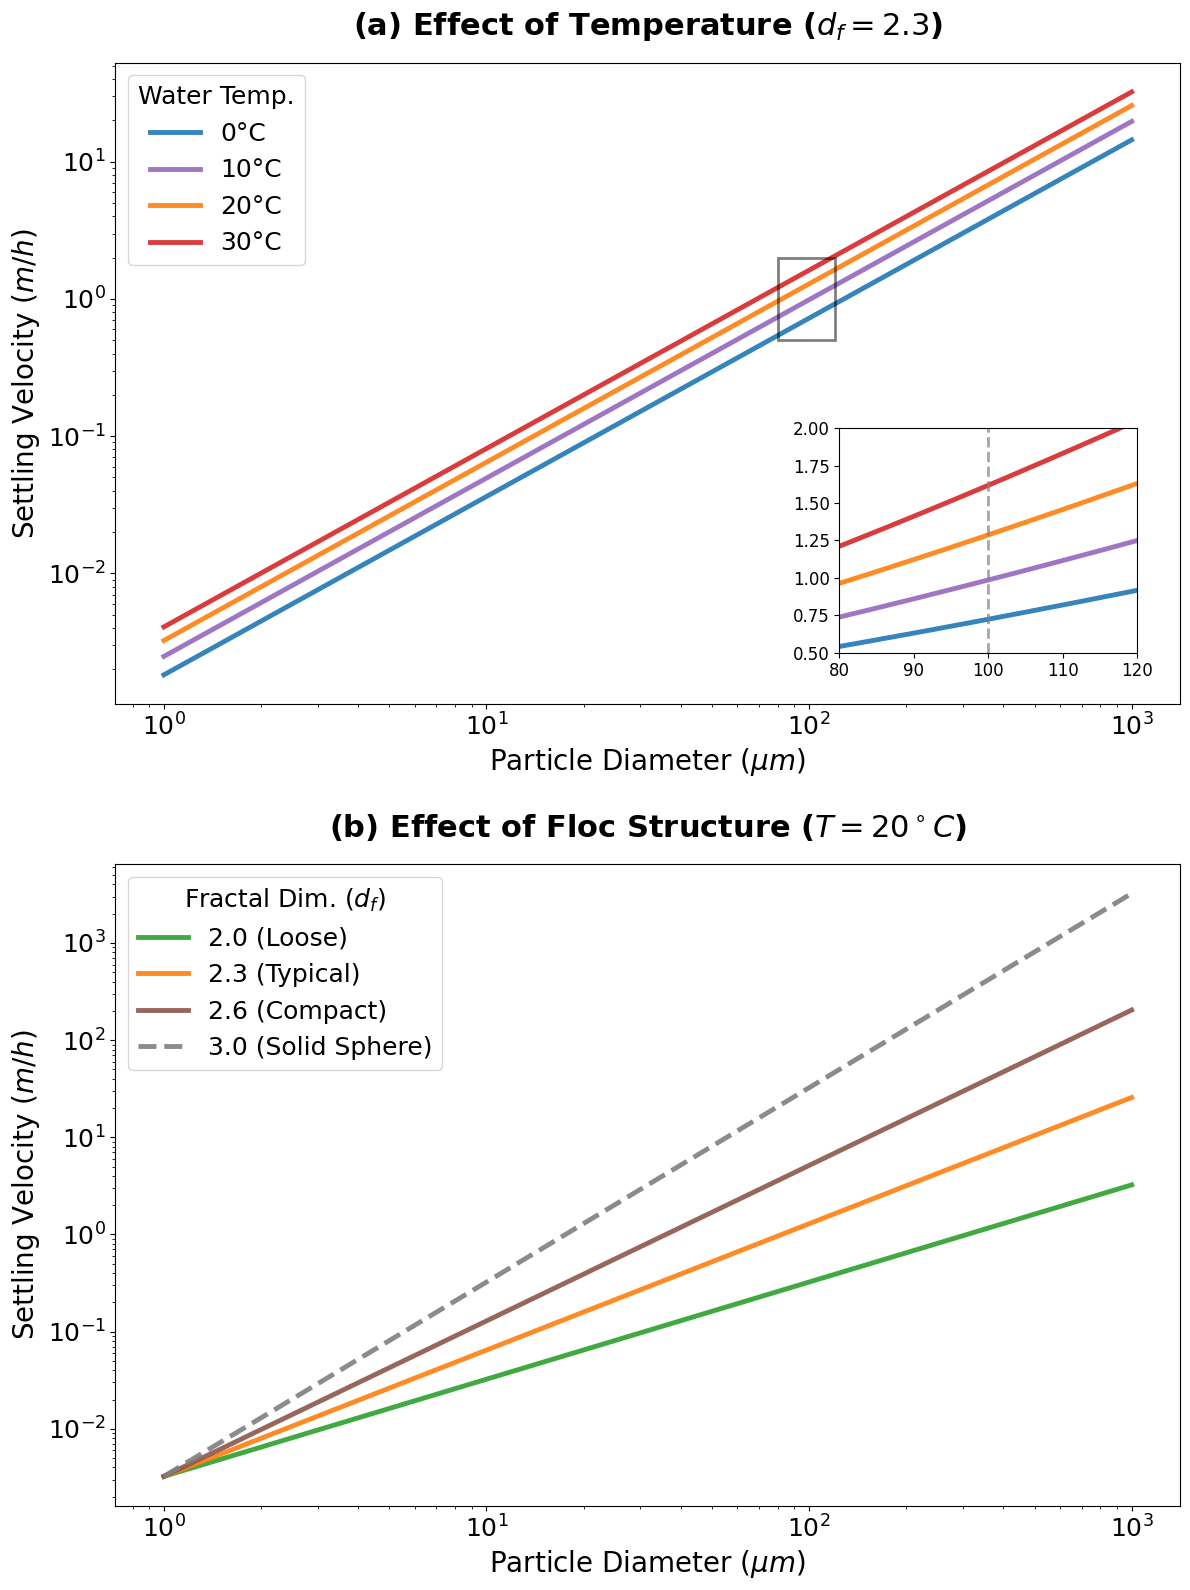

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# === 設定全域字體大小變數，方便統一管理 ===
F_TITLE = 22       # 子圖主標題 (包含 a, b)
F_LABEL = 20       # X, Y 軸標籤
F_TICKS = 18       # 刻度標籤大小 (對數刻度需要更大才清楚)
F_LEGEND = 18      # 圖例文字與圖例標題
L_WIDTH = 3.5      # 線條寬度，配合大圖與大字
A_ALPHA = 0.9      # 線條透明度

# --- 1. 基本物理參數 (保持不變) ---
g = 9.81
rho_p = 2650.0  # 原生顆粒密度 (kg/m^3)
d0 = 1e-6       # 原生顆粒直徑 (1 um)
d_array = np.logspace(-6, -3, 500) # 粒徑範圍 1 um 到 1000 um

# 溫度對應參數 (0, 10, 20, 30 °C)
temps = [0, 10, 20, 30]
rhos_w = [999.8, 999.7, 998.2, 995.7]
mus = [1.781e-3, 1.307e-3, 1.002e-3, 0.798e-3]

# --- 2. 建立 2x1 畫布 (上下堆疊) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16))

# ==============================================================================
# 上圖 (a)：探討「溫度」的影響 (固定 df = 2.3)
# ==============================================================================
df_fixed = 2.3
colors_t = ['#1f77b4', '#9467bd', '#ff7f0e', '#d62728']

# --- 建立局部放大圖 (Inset) 物件 ---
# 修改點：縮小視窗比例，[x位置, y位置, 寬度比例, 高度比例]
# 寬度從 0.35 降為 0.28，高度從 0.45 降為 0.35，並稍微向右靠 (x位置從 0.62 改為 0.68)
axins = ax1.inset_axes([0.68, 0.08, 0.28, 0.35]) 

for T, rho_w, mu, color in zip(temps, rhos_w, mus, colors_t):
    rho_floc = rho_w + (rho_p - rho_w) * (d0 / d_array)**(3 - df_fixed)
    vs_ms = (g * (rho_floc - rho_w) * d_array**2) / (18 * mu)
    vs_mh = vs_ms * 3600 
    
    # 畫在主圖上
    ax1.plot(d_array * 1e6, vs_mh, label=f'{T}°C', color=color, lw=L_WIDTH, alpha=A_ALPHA)
    # 同時畫在局部放大圖上
    axins.plot(d_array * 1e6, vs_mh, color=color, lw=L_WIDTH, alpha=A_ALPHA)

# --- 設定上圖 (a) 的主圖格式 ---
ax1.set_title(f'(a) Effect of Temperature ($d_f = {df_fixed}$)', fontsize=F_TITLE, fontweight='bold', pad=20)
ax1.set_xlabel('Particle Diameter ($\mu m$)', fontsize=F_LABEL)
ax1.set_ylabel('Settling Velocity ($m/h$)', fontsize=F_LABEL)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.tick_params(axis='both', which='major', labelsize=F_TICKS)
ax1.tick_params(axis='both', which='minor', labelsize=F_TICKS)
ax1.legend(title='Water Temp.', fontsize=F_LEGEND, title_fontsize=F_LEGEND, loc='upper left', framealpha=0.8)

# --- 設定局部放大圖 (Inset) 的格式 ---
axins.set_xlim(80, 120)
axins.set_ylim(0.5, 2.0)
axins.set_xscale('linear')
axins.set_yscale('linear')
# 修改點：配合縮小的視窗，微調放大圖內的字體大小避免擁擠
axins.tick_params(labelsize=12)

# 畫一條垂直虛線標示 100 um 的基準點
axins.axvline(x=100, color='gray', linestyle='--', lw=2, alpha=0.7)

# indicate_inset_zoom 會回傳方框物件 (rect) 與四條連接線 (connects)
rect, connects = ax1.indicate_inset_zoom(axins, edgecolor="black", alpha=0.5, lw=2)

# 透過迴圈將四條連接線設為不可見，只留下原圖上的方框
for c in connects:
    c.set_visible(False)


# ==============================================================================
# 下圖 (b)：探討「分形維度」的影響 (固定 T = 20°C)
# ==============================================================================
dfs = [2.0, 2.3, 2.6, 3.0]
labels_df = ['2.0 (Loose)', '2.3 (Typical)', '2.6 (Compact)', '3.0 (Solid Sphere)']
colors_df = ['#2ca02c', '#ff7f0e', '#8c564b', '#7f7f7f']

T_fixed_idx = 2 
rho_w_fixed = rhos_w[T_fixed_idx]
mu_fixed = mus[T_fixed_idx]

for df_val, label, color in zip(dfs, labels_df, colors_df):
    if df_val == 3.0:
        rho_floc = np.full_like(d_array, rho_p) 
    else:
        rho_floc = rho_w_fixed + (rho_p - rho_w_fixed) * (d0 / d_array)**(3 - df_val)
        
    vs_ms = (g * (rho_floc - rho_w_fixed) * d_array**2) / (18 * mu_fixed)
    vs_mh = vs_ms * 3600
    
    line_style = '--' if df_val == 3.0 else '-'
    ax2.plot(d_array * 1e6, vs_mh, label=f'{label}', color=color, ls=line_style, lw=L_WIDTH, alpha=A_ALPHA)

ax2.set_title('(b) Effect of Floc Structure ($T = 20^\circ C$)', fontsize=F_TITLE, fontweight='bold', pad=20)
ax2.set_xlabel('Particle Diameter ($\mu m$)', fontsize=F_LABEL)
ax2.set_ylabel('Settling Velocity ($m/h$)', fontsize=F_LABEL)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.tick_params(axis='both', which='major', labelsize=F_TICKS)
ax2.tick_params(axis='both', which='minor', labelsize=F_TICKS)
ax2.legend(title='Fractal Dim. ($d_f$)', fontsize=F_LEGEND, title_fontsize=F_LEGEND, loc='upper left', framealpha=0.8)


# --- 3. 排版與輸出 ---
plt.tight_layout()
fig.subplots_adjust(hspace=0.25)
output_filename = 'Settling_Velocity_Stacked_With_Inset_Adjusted.png'
plt.savefig(output_filename, dpi=300)
print(f"圖表已成功儲存為 {output_filename}")

plt.show()

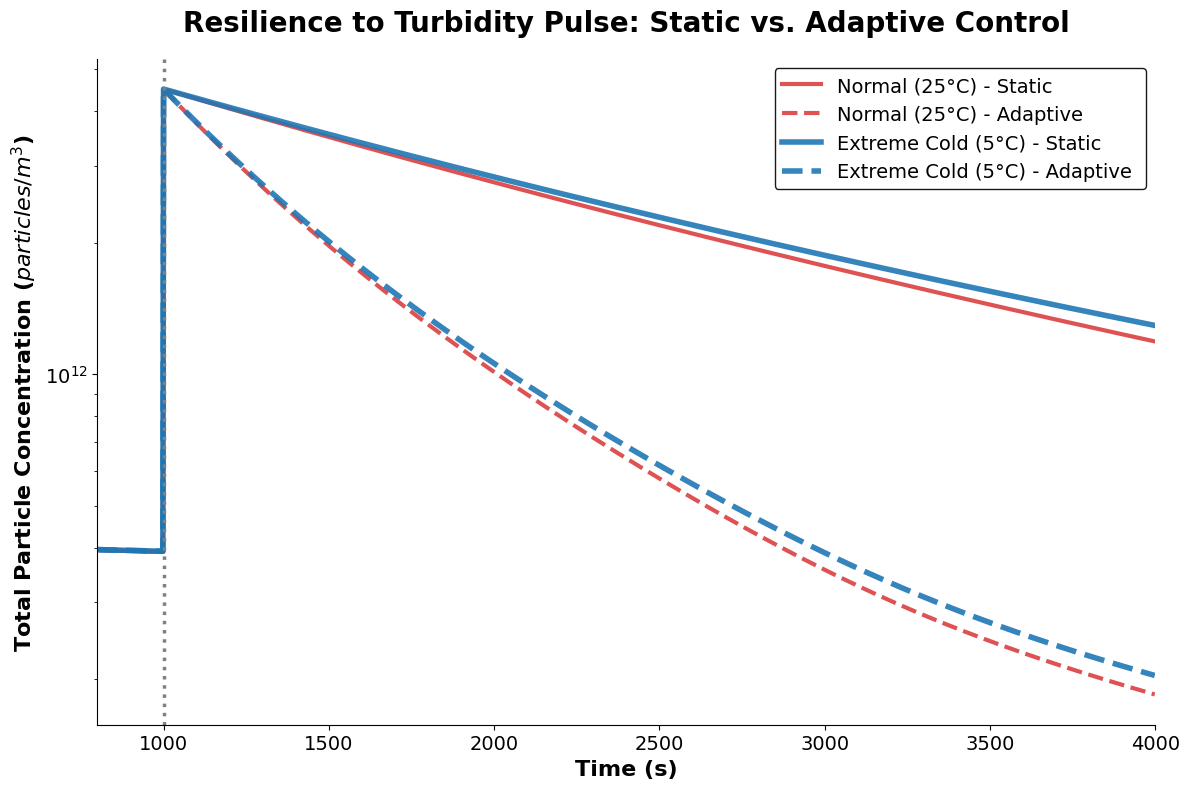

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# --- 物理參數與輔助函數 ---
kb, g, rho_p, d0, df = 1.38e-23, 9.81, 2650.0, 1e-6, 2.3

def get_water_props(temp_c):
    # 返回對應溫度的密度與黏度
    if temp_c == 5: return 1000.0, 1.518e-3
    if temp_c == 25: return 997.0, 0.890e-3
    return 998.2, 1.002e-3

def get_beta(d_bins, temp_c, mu, rho_w, G):
    T, n_bins = temp_c + 273.15, len(d_bins)
    beta = np.zeros((n_bins, n_bins))
    for i in range(n_bins):
        for j in range(n_bins):
            di, dj = d_bins[i], d_bins[j]
            b_br = (2*kb*T)/(3*mu) * (di+dj)**2 / (di*dj)
            b_sh = (1/6) * G * (di+dj)**3
            rho_fi = rho_w + (rho_p - rho_w) * (d0/di)**(3-df) if di > d0 else rho_p
            vi = (g * (rho_fi - rho_w) * di**2) / (18 * mu)
            rho_fj = rho_w + (rho_p - rho_w) * (d0/dj)**(3-df) if dj > d0 else rho_p
            vj = (g * (rho_fj - rho_w) * dj**2) / (18 * mu)
            b_ds = (np.pi/4) * (di+dj)**2 * abs(vi - vj)
            beta[i,j] = b_br + b_sh + b_ds
    return beta

def run_pulse_simulation(temp_c, adaptive=False):
    rho_w, mu = get_water_props(temp_c)
    n_bins = 40
    v0, v_bins = (np.pi/6)*d0**3, (np.pi/6)*d0**3 * (1.5**np.arange(n_bins))
    d_bins = (6*v_bins/np.pi)**(1/3)
    
    # 初始 PSD (Lognormal)
    s, mu_g = np.log(1.8), 2e-6
    N = lognorm.pdf(d_bins, s=s, scale=mu_g)
    N = N * (0.01 / rho_p / np.sum(N * v_bins))
    N_pulse_unit = N.copy()
    
    dt, total_time = 2.0, 4000
    G, alpha = 25.0, 0.5
    beta = get_beta(d_bins, temp_c, mu, rho_w, G)
    history = []
    
    for t in np.arange(0, total_time, dt):
        if abs(t - 1000) < dt/2: # 脈衝發生
            N += 10 * N_pulse_unit
            if adaptive: G, alpha = 60.0, 0.8; beta = get_beta(d_bins, temp_c, mu, rho_w, G)
        
        history.append(np.sum(N))
        dN = np.zeros(n_bins)
        for i in range(n_bins):
            for j in range(i, n_bins):
                rate = (0.5 if i==j else 1.0) * alpha * beta[i,j] * N[i] * N[j] * dt
                rate = min(rate, N[i]/2.0 if i==j else min(N[i], N[j]))
                if rate <= 0: continue
                v_new = v_bins[i] + v_bins[j]
                if v_new >= v_bins[-1]:
                    dN[i] -= rate * (2 if i==j else 1); dN[-1] += rate * (v_new/v_bins[-1])
                    if i!=j: dN[j] -= rate
                else:
                    k = np.searchsorted(v_bins, v_new, side='right') - 1
                    f = (v_bins[k+1] - v_new) / (v_bins[k+1] - v_bins[k])
                    dN[i] -= rate * (2 if i==j else 1); dN[k] += f*rate; dN[k+1] += (1-f)*rate
                    if i!=j: dN[j] -= rate
        N += dN
        
    return np.arange(0, total_time, dt), history

# --- 執行與作圖 ---
t_axis, h_warm_static = run_pulse_simulation(25)
_, h_warm_adapt = run_pulse_simulation(25, adaptive=True)
_, h_cold_static = run_pulse_simulation(5)
_, h_cold_adapt = run_pulse_simulation(5, adaptive=True)

fig, ax = plt.subplots(figsize=(12, 8))

# 繪製四條曲線 (Normal 為紅色系，Cold 為藍色系)
ax.plot(t_axis, h_warm_static, color='#d62728', lw=3, label='Normal (25°C) - Static ', alpha=0.8)
ax.plot(t_axis, h_warm_adapt, color='#d62728', lw=3, ls='--', label='Normal (25°C) - Adaptive ', alpha=0.8)
ax.plot(t_axis, h_cold_static, color='#1f77b4', lw=4, label='Extreme Cold (5°C) - Static ', alpha=0.9)
ax.plot(t_axis, h_cold_adapt, color='#1f77b4', lw=4, ls='--', label='Extreme Cold (5°C) - Adaptive ', alpha=0.9)

# 標註脈衝點 (僅保留垂直虛線，移除多餘文字)
ax.axvline(x=1000, color='gray', linestyle=':', lw=2.5)

# 設定軸與標題
ax.set_yscale('log')
ax.set_xlim(800, 4000) # 縮短前期平淡的部分，讓變化佔據主要畫面
ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
ax.set_ylabel('Total Particle Concentration ($particles/m^3$)', fontsize=16, fontweight='bold')
ax.set_title('Resilience to Turbidity Pulse: Static vs. Adaptive Control', fontsize=20, fontweight='bold', pad=20)

# 去除上方與右方邊框讓圖表更乾淨
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 優化圖例與刻度
ax.legend(fontsize=14, loc='upper right', framealpha=0.9, edgecolor='black')
ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig('turbidity_pulse_response_clean.png', dpi=300)
plt.show()